# 📘 Importing

In [1]:
import os
import operator
import pynvml

import pandas as pd

from dotenv import load_dotenv
from operator import itemgetter
from codecarbon import track_emissions
from IPython.display import Image, display

from time import sleep

C:\Users\Administrador\AppData\Local\Temp\ipykernel_43016\1761249872.py:3: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


In [2]:
from pydantic import BaseModel, Field
from typing_extensions import TypedDict, List, Literal, Annotated

In [3]:
from langgraph.graph import StateGraph, START, END

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_ollama import ChatOllama, OllamaEmbeddings

from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

from langgraph.prebuilt import create_react_agent, ToolNode
from langgraph_supervisor import create_supervisor

from langchain.tools.retriever import create_retriever_tool

from langchain_core.tools import tool, Tool

from langchain_core.output_parsers import StrOutputParser

from langchain.vectorstores import FAISS
from langchain.schema import Document

# ⚙️ Settings

In [ ]:
llm_retriever = ChatOllama(model="gpt-oss:latest")

In [5]:
embeddings_model = OllamaEmbeddings(model="mxbai-embed-large:335m")

In [6]:
def format_docs(docs: List[Document]) -> str:
    return "\n\n".join(doc.page_content for doc in docs)

In [7]:
class RetrievalMonitor:
    def __init__(self):
        self.retrieved_docs = []

    def _create_monitored_retriever_tool(self, retriever, name, description):
        def monitored_retrieval(query: str) -> str:
            docs = retriever.invoke(query)

            self.retrieved_docs.extend(docs)
            
            return format_docs(docs)
        
        return Tool(
            name=name, 
            description=description, 
            func=monitored_retrieval
        )

    def get_tool(self, retriever, name, description):
        return self._create_monitored_retriever_tool(
            retriever=retriever,
            name=name,
            description=description
        )

In [8]:
monitor = RetrievalMonitor()

In [10]:
vectorstore = FAISS.load_local(
    "../../data/vectorstore/faiss_embeddings", 
    embeddings_model, 
    allow_dangerous_deserialization=True
)

retriever = vectorstore.as_retriever(search_kwargs={"k": 20})

retriever_tool = monitor.get_tool(
    retriever=retriever,
    name="retriever-tool",
    description="""
        A tool to retrieve relevant information from a vectorstore 
        of engineer-related documents for industrial network 
        technical requests of PROFIBUS.
    """
)

In [12]:
retriever_agent = create_react_agent(
    model=llm_retriever,
    tools=[
        retriever_tool,
    ],
    name="retriever_agent",
    prompt="""
        You are an expert agent in industrial communication networks, with profound
        and extensive knowledge of the PROFIBUS protocol. Your role is to answer
        technical questions accurately and in detail, as a senior engineer would.
        Always answer in english.
    """
)

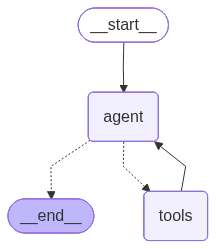

In [13]:
display(Image(retriever_agent.get_graph().draw_mermaid_png()))

# 📊 Evaluation

In [14]:
import time
from codecarbon import EmissionsTracker

In [18]:
qna_dev = pd.read_csv("../../data/QnA_dev.csv")
qna_eng = pd.read_csv("../../data/QnA_eng.csv")

In [20]:
qna_dev["response"] = ""
qna_dev["duration"] = 0.0
qna_dev["emission_kg"] = 0.0

qna_dev["retrieved_context"] = [[] for _ in range(len(qna_dev))]

tracker = EmissionsTracker(project_name="01_QnA_dev")

tracker.start()

for i, row in qna_dev.iterrows():
    monitor.retrieved_docs.clear()

    tracker.start_task(f"Question id: {row['id']}")
    start_time = time.perf_counter()

    response = retriever_agent.invoke({
        "messages": [
            {
                "role": "user",
                "content": row["question"]
            }
        ]
    })

    end_time = time.perf_counter()
    emissions_data = tracker.stop_task()

    retrieved_context = [doc.page_content for doc in monitor.retrieved_docs]

    duration = end_time - start_time

    qna_dev.at[i, "response"] = response["messages"][-1].content
    qna_dev.at[i, "duration"] = duration
    qna_dev.at[i, "emission_kg"] = emissions_data.emissions
    qna_dev.at[i, "retrieved_context"] = retrieved_context

[codecarbon WARNING @ 19:03:08] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 19:03:08] [setup] RAM Tracking...
[codecarbon INFO @ 19:03:08] [setup] CPU Tracking...
[codecarbon WARNING @ 19:03:10] We saw that you have a Intel(R) Core(TM) i9-14900K but we don't know it. Please contact us.
[codecarbon WARNING @ 19:03:10] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 19:03:10] CPU Model on constant consumption mode: Intel(R) Core(TM) i9-14900K
[codecarbon WARNING @ 19:03:10] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 19:03:10] [setup] GPU Tracking...
[codecarbon INFO @ 19:03:10] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 19:03:10] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global

In [21]:
qna_dev.to_csv("../../data/01_QnA_dev.csv")

In [22]:
qna_eng["response"] = ""
qna_eng["duration"] = 0.0
qna_eng["emission_kg"] = 0.0

qna_eng["retrieved_context"] = [[] for _ in range(len(qna_eng))]

tracker = EmissionsTracker(project_name="01_QnA_eng")

tracker.start()

for i, row in qna_eng.iterrows():
    monitor.retrieved_docs.clear()

    tracker.start_task(f"Question id: {row['id']}")
    start_time = time.perf_counter()

    response = retriever_agent.invoke({
        "messages": [
            {
                "role": "user",
                "content": row["question"]
            }
        ]
    })

    end_time = time.perf_counter()
    emissions_data = tracker.stop_task()

    retrieved_context = [doc.page_content for doc in monitor.retrieved_docs]

    duration = end_time - start_time

    qna_eng.at[i, "response"] = response["messages"][-1].content
    qna_eng.at[i, "duration"] = duration
    qna_eng.at[i, "emission_kg"] = emissions_data.emissions
    qna_eng.at[i, "retrieved_context"] = retrieved_context

[codecarbon WARNING @ 19:37:21] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 19:37:21] [setup] RAM Tracking...
[codecarbon INFO @ 19:37:21] [setup] CPU Tracking...
[codecarbon WARNING @ 19:37:22] We saw that you have a Intel(R) Core(TM) i9-14900K but we don't know it. Please contact us.
[codecarbon WARNING @ 19:37:22] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 19:37:22] CPU Model on constant consumption mode: Intel(R) Core(TM) i9-14900K
[codecarbon WARNING @ 19:37:22] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 19:37:22] [setup] GPU Tracking...
[codecarbon INFO @ 19:37:22] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 19:37:22] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global

In [23]:
qna_eng.to_csv("../../data/01_QnA_eng.csv")